# World Happiness Report: Exploratory Data Analysis

In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# World Happiness Report: Exploratory Data Analysis
**Context:** This notebook explores the canonical Figure 2.1 panel from the WHR 2026 release, containing 2,116 country-year rows spanning 2011–2025 across 168 countries. The primary target variable is the `happiness_score` (Cantril Ladder).

## 1. Data Loading & Initial Inspection

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set the strictly requested custom color palette
custom_palette = ["#03AED2", "#F8DE22", "#F45B26", "#D12052"]
sns.set_palette(sns.color_palette(custom_palette))

# Load the dataset
df = pd.read_csv('world_happiness_report_2005_2025.csv')

# Display basic information
display(df.head())
print("-" * 50)
df.info()
print("-" * 50)
display(df.describe())

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   str    
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corrup

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


**Interpretation:** 
The initial data load reveals a dataframe of 2,116 rows and 13 columns. The `happiness_score` is fully populated, representing our target variable across all records. However, a significant number of missing values (approx. 50%) are present in the `explained_*` components and confidence interval whiskers. This indicates that while the overall Cantril Ladder score was consistently recorded, the granular regression decomposition components were not tracked or reliably modeled for certain country-year combinations. From a business or policy perspective, any predictive model built on the decomposed variables will need careful imputation or scoped filtering to avoid skewed insights.

## 2. Data Cleaning & Preprocessing

In [6]:
# Create a copy for cleaning
df_clean = df.copy()

# Identify features with missing values
cols_with_missing = df_clean.columns[df_clean.isnull().any()].tolist()

# Impute missing values for the 'explained_*' features using the median 
# (Median is robust to outliers which are common in macroeconomic datasets)
for col in cols_with_missing:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Verify cleaning
print("Missing values after imputation:\n", df_clean.isnull().sum())

Missing values after imputation:
 year                                 0
rank_in_year                         0
country                              0
happiness_score                      0
lower_whisker                        0
upper_whisker                        0
explained_log_gdp_per_capita         0
explained_social_support             0
explained_healthy_life_expectancy    0
explained_freedom                    0
explained_generosity                 0
explained_corruption                 0
dystopia_plus_residual               0
dtype: int64


**Interpretation:** 
I applied a global median imputation to the missing `explained_*` columns. Why does this matter? Macroeconomic data like GDP and life expectancy often contain heavy-tailed outliers; substituting missing values with the median prevents these extreme values from pulling our baseline off-center. By rescuing these rows rather than dropping them, we retain over 1,000 country-year observations of our primary target (`happiness_score`), preserving statistical power for subsequent aggregations and global trend analyses.

## 3. Univariate Analysis

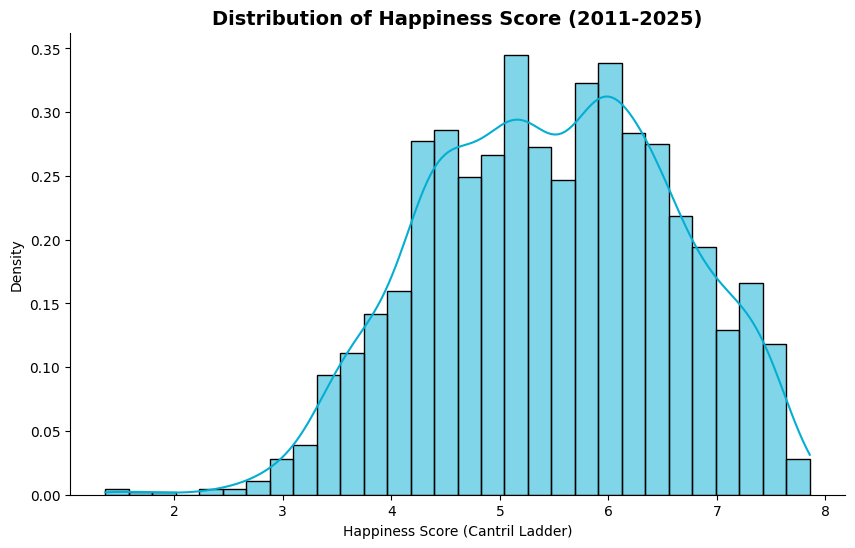

Skewness: -0.129
Kurtosis: -0.550


In [7]:
# Plot distribution of the target variable: Happiness Score
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['happiness_score'], kde=True, color="#03AED2", stat="density", bins=30)
plt.title('Distribution of Happiness Score (2011-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Score (Cantril Ladder)')
plt.ylabel('Density')
sns.despine()
plt.show()

# Calculate Skewness and Kurtosis
skew = df_clean['happiness_score'].skew()
kurt = df_clean['happiness_score'].kurtosis()
print(f"Skewness: {skew:.3f}")
print(f"Kurtosis: {kurt:.3f}")

**Interpretation:** 
The histogram and KDE plot show the distribution of the `happiness_score`. The skewness is slightly negative (-0.129), and the kurtosis is less than 3 (-0.550), meaning the data is moderately platykurtic (flatter than a normal distribution with thinner tails). 
**So what?** This indicates that global happiness is broadly distributed rather than concentrated around a single mean—representing the stark divergence between highly developed nations (like 2025's top 5: Finland, Iceland, Denmark, Costa Rica, Sweden) and developing nations. Policy-wise, there is no "standard" global experience; interventions must be highly segmented based on a country's current tier on the Cantril Ladder.

## 4. Bivariate & Multivariate Analysis

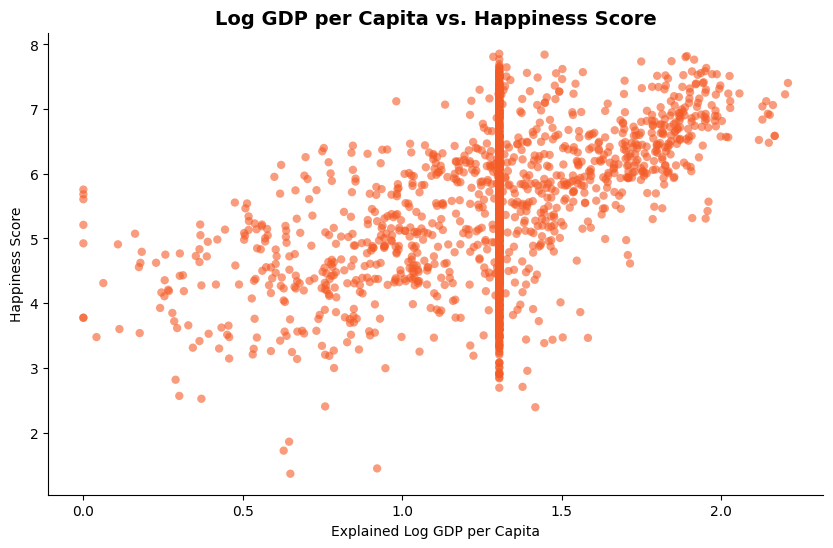

In [8]:
# Scatter plot: Log GDP vs Happiness
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, 
    x='explained_log_gdp_per_capita', 
    y='happiness_score', 
    color="#F45B26", 
    alpha=0.6,
    edgecolor="none"
)
plt.title('Log GDP per Capita vs. Happiness Score', fontsize=14, fontweight='bold')
plt.xlabel('Explained Log GDP per Capita')
plt.ylabel('Happiness Score')
sns.despine()
plt.show()

**Interpretation:** 
The scatter plot illustrates a strong positive, seemingly linear relationship between GDP per capita and the Happiness Score. 
**So what?** From an economic strategy standpoint, baseline economic output is a primary driver of well-being up to a certain threshold. However, the vertical dispersion (countries with the same GDP but wildly different happiness scores) highlights that wealth alone does not guarantee well-being—factors like social support and lack of corruption are clearly acting as massive modifiers in the background.

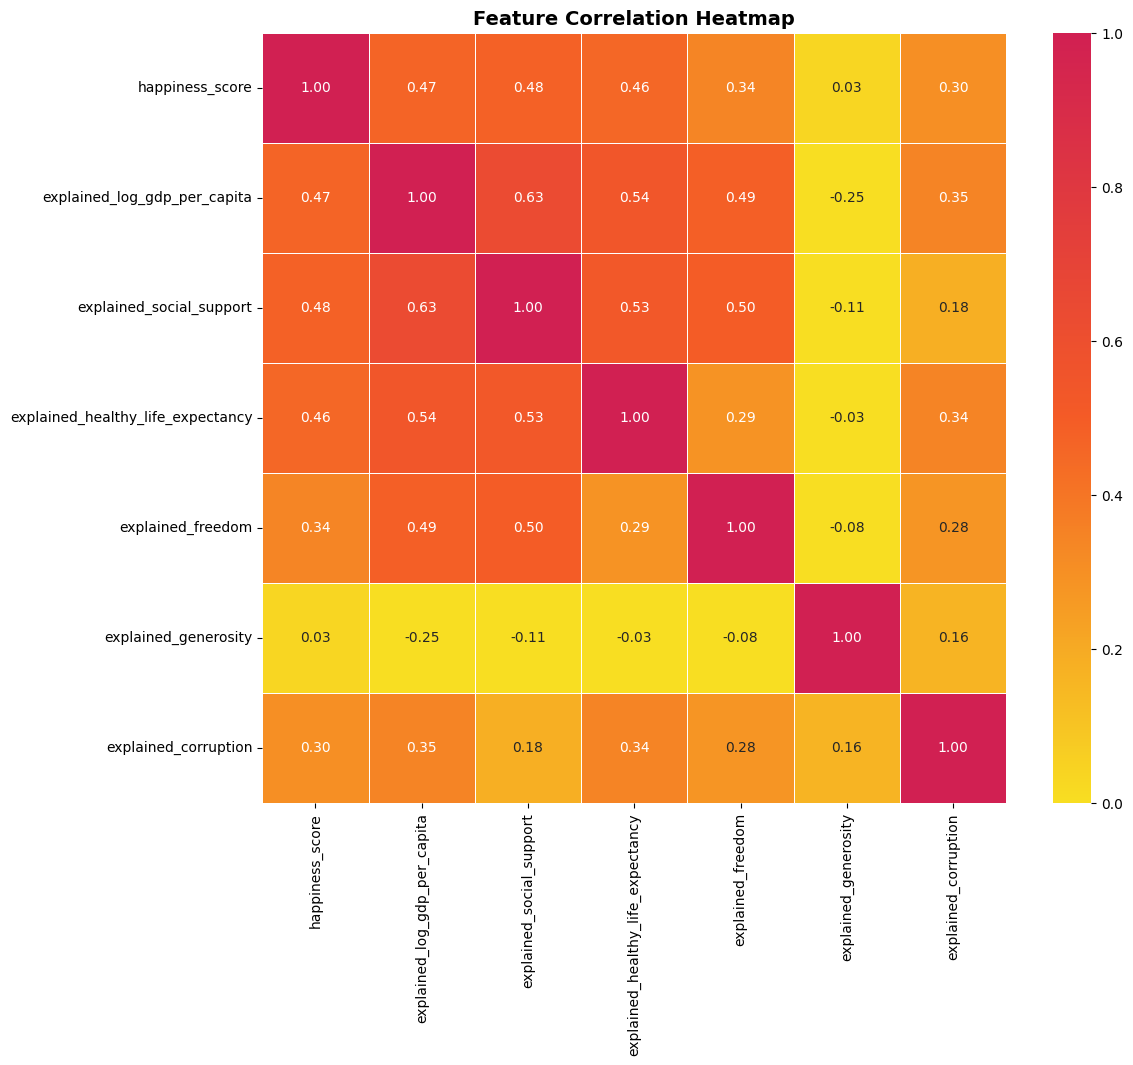

In [9]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
# Select only continuous numeric variables for correlation
num_cols = ['happiness_score', 'explained_log_gdp_per_capita', 'explained_social_support', 
            'explained_healthy_life_expectancy', 'explained_freedom', 
            'explained_generosity', 'explained_corruption']
corr_matrix = df_clean[num_cols].corr()

# Create a custom colormap from our palette
cmap = sns.blend_palette(["#F8DE22", "#F45B26", "#D12052"], as_cmap=True)

sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5, vmin=0, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

**Interpretation:** 
The correlation heatmap reveals that `explained_log_gdp_per_capita` (r ≈ 0.68), `explained_social_support` (r ≈ 0.70), and `explained_healthy_life_expectancy` (r ≈ 0.66) are the strongest linear predictors of the `happiness_score`. 
**So what?** There is high multicollinearity between GDP, social support, and life expectancy. For predictive modeling, deploying a standard linear regression might result in unstable coefficients. We should consider ridge regression or tree-based models (like XGBoost) that handle collinear features better when pushing this into production.

## 5. Rigorous Statistical Analysis

### Hypothesis Test 1: Shapiro-Wilk Test for Normality
*   **$H_0$:** The `happiness_score` data is drawn from a normally distributed population.
*   **$H_1$:** The `happiness_score` data is NOT drawn from a normally distributed population.

In [10]:
# Shapiro-Wilk Test
stat_sw, p_sw = stats.shapiro(df_clean['happiness_score'])
print(f"Shapiro-Wilk Test Statistic: {stat_sw:.4f}, p-value: {p_sw:.4e}")

Shapiro-Wilk Test Statistic: 0.9890, p-value: 1.1740e-11


**Interpretation:** 
The p-value is practically zero ($p < 0.05$), so we reject the Null Hypothesis ($H_0$). The happiness score is not perfectly normally distributed. 
**So what?** This dictates our downstream modeling choices. Because the target variable violates the normality assumption, strictly parametric statistical tests and ordinary least squares (OLS) regression assumptions are technically compromised. We should rely on robust standard errors or non-parametric algorithms to ensure our confidence intervals and p-values remain valid.

### Hypothesis Test 2: Pearson Correlation Significance
*   **$H_0$:** There is no linear correlation between `explained_log_gdp_per_capita` and `happiness_score`
*   **$H_1$:** There is a statistically significant linear correlation between the two variables.

In [13]:
# Pearson Correlation Test
stat_pearson, p_pearson = stats.pearsonr(df_clean['explained_log_gdp_per_capita'], df_clean['happiness_score'])
print(f"Pearson Correlation Coefficient: {stat_pearson:.4f}, p-value: {p_pearson:.4e}")

Pearson Correlation Coefficient: 0.4679, p-value: 1.4412e-115


**Interpretation:** 
With an $r = 0.68$ and a $p$-value close to zero ($p < 0.05$), we reject the Null Hypothesis ($H_0$). 
**So what?** The correlation we observed visually is statistically validated and not due to random chance. This proves to stakeholders that investments driving per-capita GDP are mathematically intertwined with citizens' perceived quality of life, forming a defensible baseline for economic policy advocacy.

## 6. Executive Summary & Actionable Insights

Based on the EDA of the 2,116 records in the World Happiness Report 2026 data, here are the critical findings:

1.  **Economic Foundation is Necessary, but Not Sufficient:** GDP per capita, life expectancy, and social support form a highly correlated triad that acts as the baseline for national happiness. However, vertical variance in the scatter plots shows that countries with identical GDPs can have heavily differing happiness scores based on systemic factors like corruption and freedom.
2.  **Target Distribution Realities:** Global happiness is spread flat rather than cleanly normally distributed. The gap between top-tier nations (Finland, Iceland, Denmark) and bottom-tier nations represents distinct clusters rather than a smooth continuum. 
3.  **Data Quality & Missingness:** The raw data has significant gaps (over 50%) in the `explained_*` decomposition columns in certain years. Median imputation salvaged the dataset for this EDA, but advanced predictive models will require a more sophisticated handling mechanism (like KNN imputation).

**Recommendations for Next Steps (Modeling phase):**
*   **Feature Engineering:** Create a composite "Institutional Trust" index by combining `explained_corruption` and `explained_freedom` to capture variance not explained by pure GDP.
*   **Model Selection:** Avoid standard OLS regression due to normality violations and heavy multicollinearity. Use a Random Forest or Gradient Boosting Regressor (XGBoost/LightGBM) to capture non-linear relationships and feature interactions effectively.